# 🏠 House Price Prediction Model (Beginner-Friendly Notebook)

This notebook teaches you step-by-step how to build a machine learning model to predict house prices.

## 1. Import Libraries
We import tools for data handling, visualization, and modeling.

In [1]:
import warnings
from glob import glob

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.simplefilter(action="ignore", category=FutureWarning)

# pip install category_encoders

## 2. Load Dataset

In [2]:
housing_df = pd.read_csv("C:/Users/M.faisal/Desktop/ai_ml/ai_ml_projects/3Logy-NDI-AI-ML-Crash/datasets/AmesHousing.csv")
housing_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3. Let's Explore the data

In [3]:
# Summary statistics
housing_df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [4]:
housing_df.info()
# housing_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [5]:
# Checking for null values accross all features `head`
housing_df.isna().sum().head(15)

Order              0
PID                0
MS SubClass        0
MS Zoning          0
Lot Frontage     490
Lot Area           0
Street             0
Alley           2732
Lot Shape          0
Land Contour       0
Utilities          0
Lot Config         0
Land Slope         0
Neighborhood       0
Condition 1        0
dtype: int64

In [6]:
# Checking for null values accross all features `tail`
housing_df.isna().sum().tail(15)

Wood Deck SF         0
Open Porch SF        0
Enclosed Porch       0
3Ssn Porch           0
Screen Porch         0
Pool Area            0
Pool QC           2917
Fence             2358
Misc Feature      2824
Misc Val             0
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
dtype: int64

In [7]:
# Summing the null counts for each feature `head`
housing_df.isnull().sum().sort_values(ascending=False).head(30)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
Lot Shape            0
Street               0
Lot Area             0
dtype: int64

## 4. Data Cleaning
The first thing we need to consider during exploration is **missing values**. While it's true you can impute missing values, there still needs to be enough data in a column to do a good imputation. A general rule is that, if more than half of the data in a column is missing, it's better to drop it then try imputing.

Take a look at the output from `df.info()` above. Are there columns where more than half of the values are `NaN`? If so, those columns need to go! 

**Step 1**: Decide — Drop vs Impute

From our remaining missing values:

High missing (still large enough to consider dropping)
- **Fireplace Qu → 1422** (~48%); Borderline — but important insight:

In this dataset, missing often means “No fireplace”, not “unknown”

- Keep + impute with "None"

**Step 2**: Medium missing (handle carefully)
| Feature                                               | Strategy                                       |
| ----------------------------------------------------- | ---------------------------------------------- |
| `Lot Frontage` (490)                                  | Impute with **median grouped by neighborhood** |
| Garage-related (`Garage Type`, `Garage Finish`, etc.) | Missing = **"No Garage"**                      |
| Basement-related (`Bsmt Qual`, etc.)                  | Missing = **"No Basement"**                    |

**Step 3**: Low missing (easy wins)

In [8]:
# Preprocessing Function
def preprocess_housing(df):
    df = df.copy()
    
    # 1. Drop high-missing columns (>50%)
    missing_ratio = df.isnull().sum() / len(df)
    cols_to_drop = missing_ratio[missing_ratio > 0.5].index
    df = df.drop(columns=cols_to_drop)
    
    # 2. CATEGORICAL: Fill "None"
    none_cols = [
        'Fireplace Qu',
        'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
        'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
        'Bsmt Qual', 'Bsmt Cond'
    ]
    
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")
    
    # 3. NUMERICAL: Fill with 0
    zero_cols = [
        'Mas Vnr Area',
        'Bsmt Full Bath', 'Bsmt Half Bath',
        'Garage Cars', 'Garage Area'
    ]
    
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    # 4. Lot Frontage (important!)
    if 'Lot Frontage' in df.columns and 'Neighborhood' in df.columns:
        df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage']\
                               .transform(lambda x: x.fillna(x.median()))
    
    # 5. Remaining numerical → median
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    
    # 6. Remaining categorical → mode
    cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
    
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    return df

In [9]:
# Original shape
housing_df.shape

(2930, 82)

In [28]:
# Apply function
df_clean = preprocess_housing(housing_df)
df_clean.head(15)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,Reg,Lvl,AllPub,...,170,0,0,0,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,...,0,0,144,0,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,6,2010,WD,Normal,189000


In [11]:
# Checking for null values accross all features
df_clean.isna().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 77, dtype: int64

### Pairplot (What & Why):

A **pairplot** is a visualization technique (commonly from Seaborn) that shows pairwise relationships between multiple variables in a dataset. It creates a grid of scatterplots for each combination of features, along with distributions (histograms or KDE plots) on the diagonal.

**We use a pairplot here to:**

- Visually explore how different features relate to SalePrice
- Detect patterns such as linear relationships, clusters, or outliers
- Quickly identify which features may be useful predictors for our model

### Correlation (What & Why):

**Correlation** measures the strength and direction of the relationship between two numerical variables. It ranges from:

- +1 → strong positive relationship
- 0 → no relationship
- -1 → strong negative relationship

In this project, we calculate the correlation between each feature and SalePrice to:

- Identify which features are most strongly related to the target
- Reduce noise by focusing only on meaningful variables

### Why We Select Only Top 10 Features:

Using all features in a pairplot would:

- Create a very large and cluttered visualization
- Make it hard to interpret relationships clearly
- Slow down computation significantly

Instead, we select the top 10 features with the highest correlation to SalePrice because:

- They are the most informative predictors
- The visualization becomes cleaner and easier to understand
- It helps us focus on what truly matters for modeling

### Key Idea:

Rather than visualizing everything, we:
- Use correlation to filter important features, then use pairplot to explore them visually

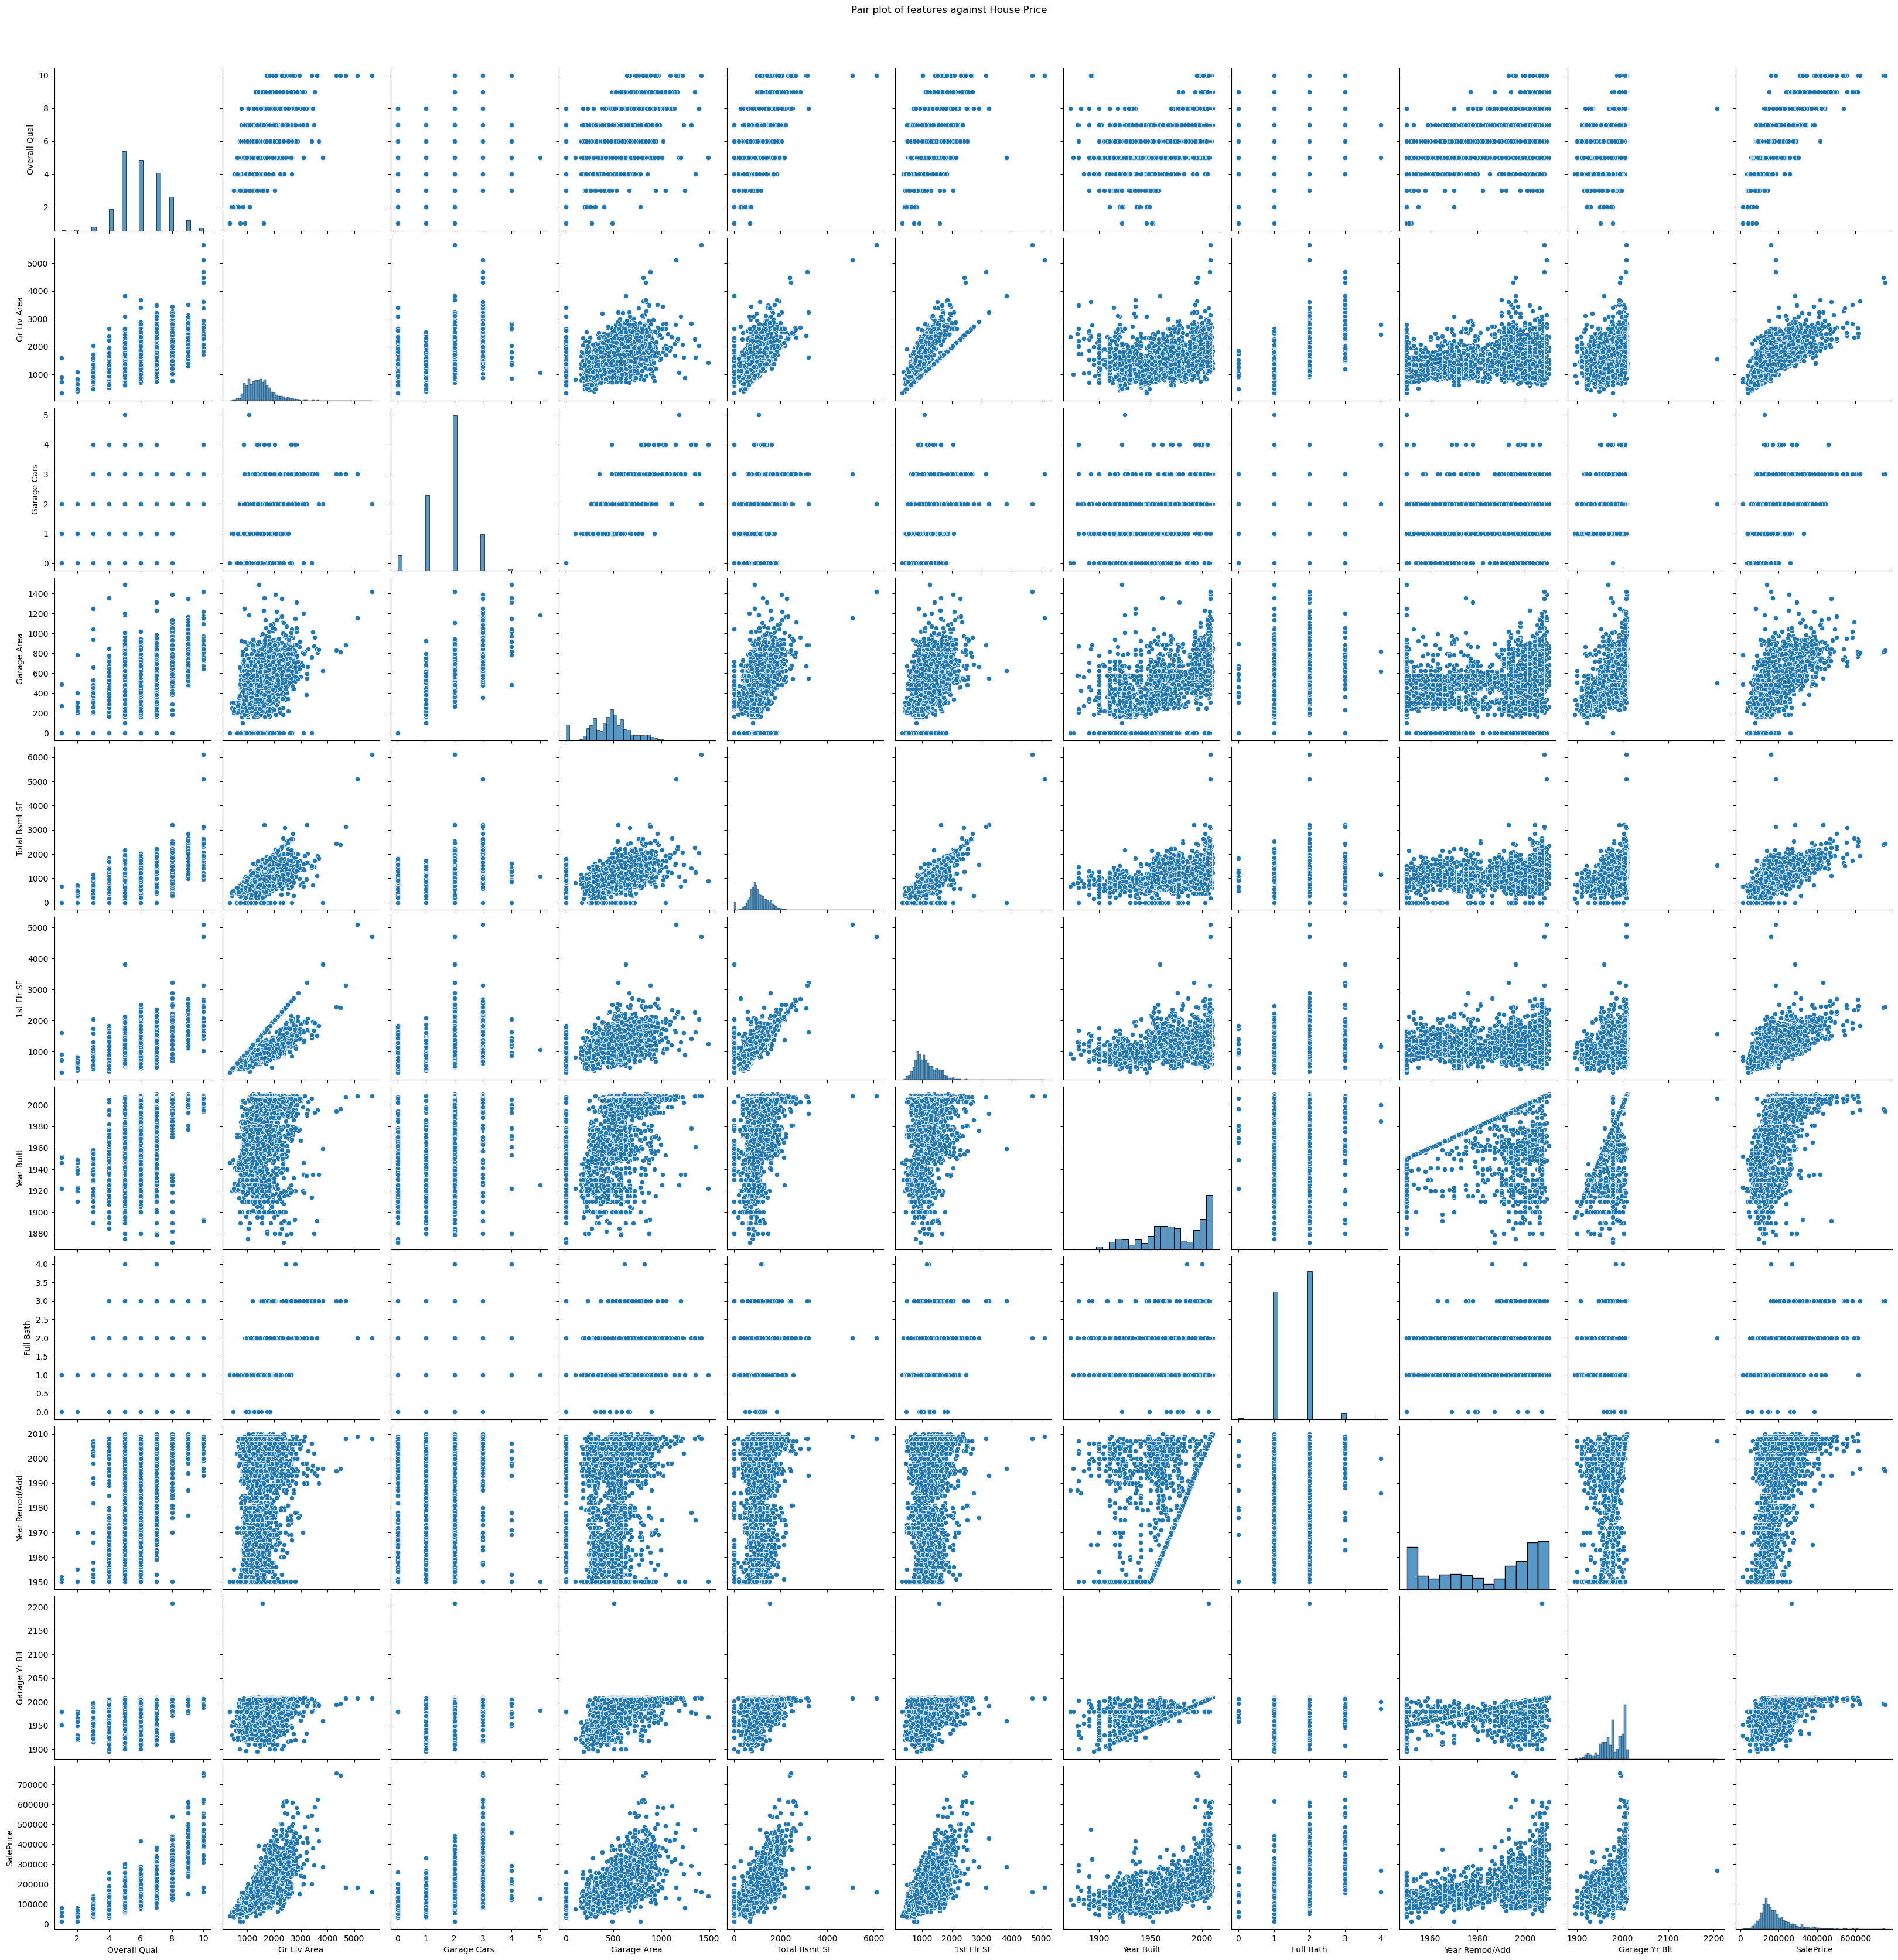

In [12]:
#Get top correlations
corr = df_clean.corr(numeric_only=True)
top_corr = corr['SalePrice'].abs().sort_values(ascending=False)
top_features = top_corr[1:11].index  # Top 10 features (excluding SalePrice)
housing_df_imp = df_clean[top_features.tolist() + ['SalePrice']]

# Visualizing pairwise relationships in the housing_df feature against housePrice using a pairplot
sns.pairplot(
    # df_clean[top_features.tolist() + ['SalePrice']],
    housing_df_imp,
    height=3
)
plt.suptitle("Pair plot of features against House Price", y=1.02)
plt.show()

### How to Interpret Your Pairplot
Think of the pairplot as answering ONE question repeatedly:
- *“How does this feature relate to SalePrice?”*

## What to Look for in a Pairplot

### 1. Relationship with `SalePrice` (MOST important)

* Look at plots where `SalePrice` appears
* Ask: **Is there a clear trend?**

**What you’ll see:**

* Upward line → ✅ strong positive relationship (good feature)
* No pattern → ❌ weak feature
* Downward line → ⚠️ negative relationship

---

### 2. Strength of the pattern

* Tight, narrow pattern → ✅ strong predictor
* Wide, scattered points → ⚠️ weaker predictor

---

### 3. Shape of the relationship

* Straight line → linear (good for linear models)
* Curve → non-linear (may need transformation)

---

### 4. Distribution (diagonal plots)

* Check if data is **skewed**
* Long tail → consider **log transform**

---

### 5. Outliers

* Points far away from others
* Can distort your model → may need removal

---

### 6. Feature type clues

* Vertical/horizontal stripes → categorical or discrete feature
* Smooth spread → continuous feature

---

### In summary

> Look for **clear patterns, strong trends, and unusual points** between features and `SalePrice`.


In [13]:
housing_df_imp.head()

,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,Year Remod/Add,Garage Yr Blt,SalePrice
0,6,1656,2.0,528.0,1080.0,1656,1960,1,1960,1960.0,215000
1,5,896,1.0,730.0,882.0,896,1961,1,1961,1961.0,105000
2,6,1329,1.0,312.0,1329.0,1329,1958,1,1958,1958.0,172000
3,7,2110,2.0,522.0,2110.0,2110,1968,2,1968,1968.0,244000
4,5,1629,2.0,482.0,928.0,928,1997,2,1998,1997.0,189900


<Axes: >

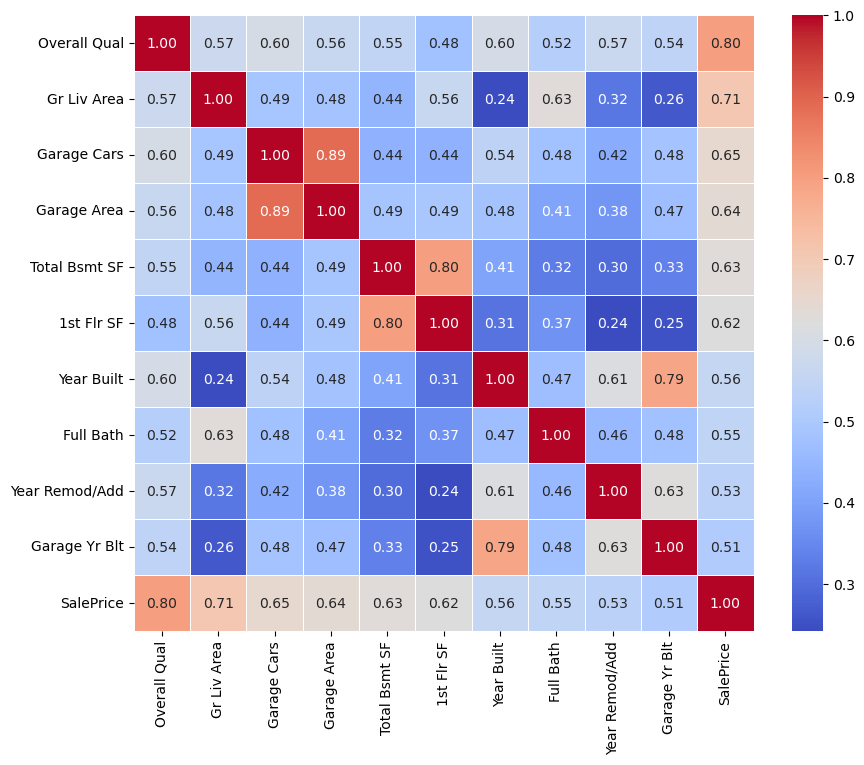

In [14]:
# Checking for multicollinearity using the variance inflation factor (VIF) for each predictor
# Compute the correlation variable using heatmap
corr = housing_df_imp.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

As you can see above, the heatmap displays correlation coefficients b/t housing related variables with values ranging from -1 blue to 1 red

In [15]:
# Compute and display the absolute correlation values of HousePrice sorting them in descending order
corr["SalePrice"].abs().sort_values(ascending=False)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647562
Garage Area       0.640138
Total Bsmt SF     0.632164
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.508882
Name: SalePrice, dtype: float64

The above absolute correlation facilitates the identification of the most influential indicators strongly associated with SalePrice e.g Overall Qual is a strong positive indicator for predicting house price.

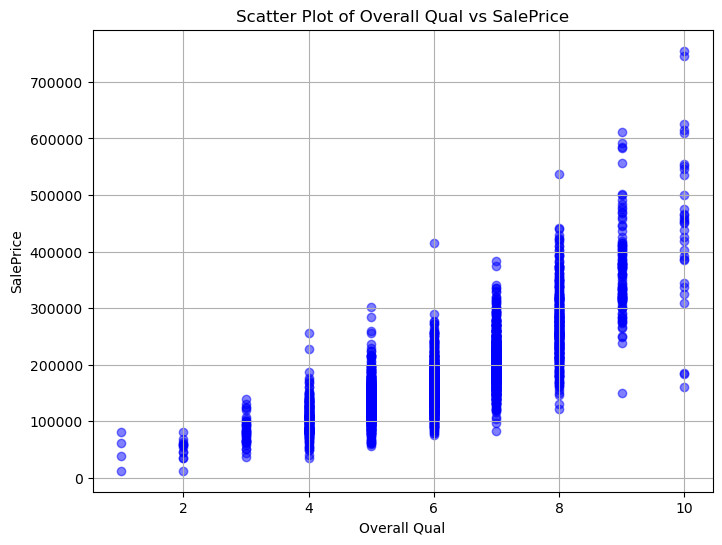

In [16]:
# Scatter plot to display the relationship bt MedInc and HousePrice
overall_qua = housing_df_imp['Overall Qual']
saleprice = housing_df_imp['SalePrice']

plt.figure(figsize=(8,6))
plt.scatter(overall_qua, saleprice, alpha=0.5, color='blue')
plt.title("Scatter Plot of Overall Qual vs SalePrice")
plt.xlabel("Overall Qual")
plt.ylabel("SalePrice")
plt.grid(True)
plt.show()

### What is Multicollinearity?

**Multicollinearity** happens when:

> Two or more features are **highly correlated with each other**

👉 Meaning:

* They carry **almost the same information**. When you're creating a linear model that uses many features to make predictions, some of those features can be highly correlated with each other. This isn't a problem that's going to break your model; it will still make predictions and it might have good performance metrics. But it is an issue if you want to interpret the coefficients for your model because it becomes hard to tell which features are truly important.
---

### Why it’s a problem

Especially for models like **Linear Regression**:

* Coefficients become **unstable**
* Model struggles to know **which feature is actually important**
* Can lead to **overfitting**
* Interpretation becomes unreliable
---

### How to Identify it (using our heatmap above)
A **correlation heatmap** shows the relative strength of correlations between the variables in a dataset.

### Rule of thumb:

* Correlation **> 0.8** between features → multicollinearity risk

---

### Interpretation of the heatmap above

### Strong multicollinearity detected:

#### 1. `Garage Cars` ↔ `Garage Area` → **0.89**

Very high:

- * Both describe garage size
- * Keeping both = redundant

**Keep one, drop the other**
Usually keep `Garage Cars` (simpler, cleaner)

---

#### 2. `Total Bsmt SF` ↔ `1st Flr SF` → **0.80**

Strong relationship

* Bigger basement → bigger first floor (logical)

Keep one or test both

---

#### 3. `Year Built` ↔ `Garage Yr Blt` → **0.79**

Almost same info

* Garage often built same year as house

Drop one (usually `Garage Yr Blt`)

---

### Features strongly related to `SalePrice`

These are GOOD:

* `Overall Qual` → **0.80** 🔥
* `Gr Liv Area` → **0.71**
* `Garage Cars` → **0.65**
* `Garage Area` → **0.64**
* `Total Bsmt SF` → **0.63**

These are the **key predictors**

---

### What we should do next? (practical strategy)

**Step 1**: Remove redundant features

**Step 2**: Be careful (don’t drop blindly)

If two features:

- * Highly correlated with each other ✅
- * AND both strongly related to target

You can:

- * Keep both (for tree models)
- * Or test performance

---

### How to read the heatmap (simple rule)

### Look for:

* Bright red squares **outside the diagonal**

That means:

> Feature vs Feature correlation is high

---

### Summary

### Multicollinearity:

> Features telling the same story

### Problems:

* Confuses model
* Unstable coefficients

### Detection:

* Heatmap → look for **> 0.8**
* VIF → numerical confirmation

### Fix:

* Drop one of the correlated features
* Keep the one:

  * More interpretable
  * More correlated with target

---

### Pro Insight (Rule you should remember)

> “More features” ≠ “Better model”

Clean, independent features = **better performance**.

**Note**:
A feature can be useful AND redundant at the same time.

That’s why we:
- First → find useful features (correlation with target)
- Then → remove redundancy (multicollinearity)

---

### What is VIF (Variance Inflation Factor)?

VIF (Variance Inflation Factor) measures how much a feature is explained by other features in your dataset.
In simple terms:
- VIF tells you how “redundant” a feature is when predicting using the other features.
| VIF Value | Meaning                                |
| --------- | -------------------------------------- |
| 1         | No multicollinearity                   |
| 1–5       | Acceptable                             |
| 5–10      | Moderate multicollinearity             |
| >10       | Severe multicollinearity (problematic) |

### Why VIF is Important

Multicollinearity causes:
- Unstable coefficients (linear regression breaks interpretability)
- Redundant features (wastes model capacity)
- Inflated importance of correlated variables
- Poor generalization in linear models

### Important Reality Check
VIF is mainly critical for:
- Linear Regression
- Logistic Regression
- GLMs

Less critical for:
- Random Forest
- XGBoost
- Neural Networks

BUT still useful for:
Feature reduction and interpretability

In [17]:
# Calculating the variance inflating factor VIF for each feature in the housing dataset, to identify multicollinearity; the VIF helps determine the
# correlation bt the predictors and drop features with high VIF values
housing_df_vif = housing_df_imp.drop("SalePrice", axis=1)
# Keep only numeric
housing_df_vif = housing_df_vif.select_dtypes(include=['int64', 'float64'])
# Drop remaining NaNs
housing_df_vif = housing_df_vif.dropna()
housing_df_vif = housing_df_vif.apply(pd.to_numeric, errors='coerce')

vif_data = pd.DataFrame()
vif_data["Feature"] = housing_df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(housing_df_vif.values, i) for i in range(len(housing_df_vif.columns))]
vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
9,Garage Yr Blt,17857.507421
6,Year Built,14094.507774
8,Year Remod/Add,11422.986905
0,Overall Qual,44.340283
2,Garage Cars,35.706196
5,1st Flr SF,32.730513
3,Garage Area,31.266359
1,Gr Liv Area,24.002792
4,Total Bsmt SF,21.664237
7,Full Bath,17.237183


From the above outout, Garage Area and Garage Yr Blt, Year Remod/Add, have exceptionaly high VIF values indicating severe multicollinearity with other predicting fetaures; addressing this is crucial for improving model stability and interpretability. 

| VIF  | Meaning              |
| ---- | -------------------- |
| 1–5  | ✅ Good               |
| 5–10 | ⚠️ Moderate          |
| >10  | 🚨 High (fix needed) |


In [18]:
# Remove redundant features
cols_to_drop = [
    'Garage Area',      # duplicate of Garage Cars
    'Garage Yr Blt',    # duplicate of Year Built
    '1st Flr SF',       #they all measure size
]

df_model = housing_df_imp.drop(columns=cols_to_drop)
df_model.head()

,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Year Built,Full Bath,Year Remod/Add,SalePrice
0,6,1656,2.0,1080.0,1960,1,1960,215000
1,5,896,1.0,882.0,1961,1,1961,105000
2,6,1329,1.0,1329.0,1958,1,1958,172000
3,7,2110,2.0,2110.0,1968,2,1968,244000
4,5,1629,2.0,928.0,1997,2,1998,189900


### Define Features, Target & Fit

In [19]:
#Converting selected columns in the housing dataset to numeric
cols_to_convert = [ "Overall Qual", "Gr Liv Area", "Garage Cars", "Total Bsmt SF", "Year Built", "Full Bath", "Year Remod/Add"]
df_model[cols_to_convert] = df_model[cols_to_convert].apply(pd.to_numeric, errors="coerce")
df_model["SalePrice"] = pd.to_numeric(df_model["SalePrice"], errors="coerce")

# Adding constant to the features
X = sm.add_constant(df_model.drop("SalePrice", axis=1))
y = df_model["SalePrice"]

# # log-transforming SalePrice to reduce the effect of extremely expensive houses:
# y_log = np.log(y)
# model = sm.OLS(y_log, X).fit()
# fit using an OLS Regression models using start model
model = sm.OLS(y, X).fit()

### What are residuals?
In regression, the **residual** for each observation is the **difference between the actual value and the predicted value**:

`Residual = y-actual - y-predicted`

* `y_actual` → the true SalePrice in the dataset
* `y_predicted` → the SalePrice predicted by the regression model

So, **residuals measure the “error”** of our model for each data point.

* **Positive residual** → model **underestimated** the actual SalePrice
* **Negative residual** → model **overestimated** the actual SalePrice
* **Residual ≈ 0** → model prediction is very close to the actual value

Residuals are critical because they tell us **how well the model fits the data** and whether **OLS assumptions** are met.

---

### Interpreting the residual analysis plots

1. **Residuals distribution (histogram + KDE)**


* This shows how residuals are distributed.
* **Ideal OLS assumption**: residuals are roughly **normally distributed** around 0.
* **Interpretation**:
  * If the histogram is roughly bell-shaped → model residuals are normal → good.
  * If residuals are skewed (long tail left or right) → maybe log-transform `SalePrice` to stabilize variance.

---

2. **Residuals vs Predicted Values (scatter)**

* X-axis → predicted SalePrice
* Y-axis → residuals

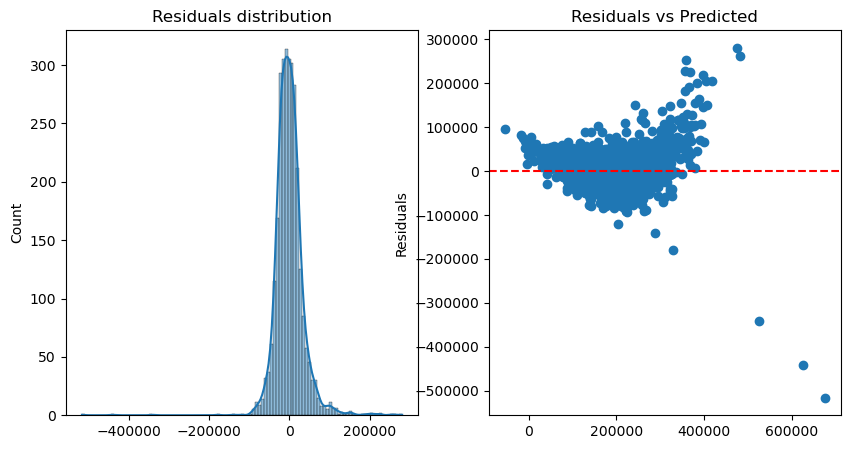

Model coefficients:
 const            -1.226013e+06
Overall Qual      1.950912e+04
Gr Liv Area       5.639172e+01
Garage Cars       1.335696e+04
Total Bsmt SF     3.338078e+01
Year Built        2.750974e+02
Full Bath        -9.513137e+03
Year Remod/Add    3.110604e+02
dtype: float64


In [20]:
# Lets perform residual analysis to validate linear regresion assumptions and 
# visualize the distribution of residuals and their relationship with predicted values
residuals = model.resid

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")

plt.subplot(1,2,2)
plt.scatter(model.predict(X), residuals)
plt.axhline(y=0, color="red", linestyle='--')
plt.title("Residuals vs Predicted")
plt.ylabel("Residuals")
plt.show()

print("Model coefficients:\n", model.params)

From above diagram, 
- The Histogram displays somewhat normal distribution with normal tail suggesting the presence of outliers and residuals
- The scatter plot shows the residuals against predicted values, Ideally random scatter arround the 0 line is expected but there are some residuals with partivulary large positive or large negative indicating potential outliers affecting the model accuracy
- The model coefficients indicates the impact of each feature against SalePrice; Overall Qual shows the most significant positive influence

**Observation from above**:
Overall Qual has the largest positive coefficient (19,509).
This means for each 1-point increase in Overall Qual, predicted SalePrice increases by $19,509, holding other features constant.
Even though Gr Liv Area and Total Bsmt SF affect price per square foot, their per-unit influence is much smaller than Overall Qual.


**What to look for:**

| Pattern in scatter                             | Interpretation                                            |
| ---------------------------------------------- | --------------------------------------------------------- |
| Random scatter around 0                        | Good → linearity & homoscedasticity assumptions hold      |
| Funnel shape (spread increases with predicted) | Heteroscedasticity → variance of errors is not constant   |
| Curved pattern                                 | Nonlinearity → maybe need polynomial or interaction terms |
| Clusters                                       | Maybe missing variables or group effects                  |

**Red line** at y=0 is the baseline — residuals should be centered around it.

---

### Interpreting your results in context

* From the OLS regression, **residuals are the prediction errors** of your model.
* The residual histogram and scatter help you check if your model assumptions hold.

**Based model**:

* Coefficients like `Overall Qual` (19,509) and `Gr Liv Area` (56.39) tell **how much each unit of feature contributes to predicted SalePrice**.
* Residuals tell you **how far your predictions are from actual SalePrice**.

**So together**:
* Coefficients → measure **feature influence**
* Residuals → measure **model accuracy** and check **assumptions**

In [21]:
# Compute and interprete the R^2 and MSE Metrics to evaluate the performance of the L.R model on the housing data. 
predictions = model.predict(X)
# Baseline RMSE score
rmse_baseline = np.sqrt(mean_squared_error(y, predictions))

print("R square Score:", r2_score(y, predictions))
print("MSE:", mean_squared_error(y, predictions))
print("Baseline RMSE:", rmse_baseline)
print("Baseline MAE:", mean_absolute_error(y, predictions))

R square Score: 0.7919254179073826
MSE: 1327454555.4563537
Baseline RMSE: 36434.24975838467
Baseline MAE: 23887.314377011404


So, from the above metrics, the model explains approximately 80% of the variance in the dependent variable with a mean squared error of 36434.25 indicating moderate predictive performance.

The baseline results establish a simple but important benchmark for model performance. The Mean Absolute Error (MAE) of 23887.314 means that, on average, predictions made by this naive model (which always predicts the mean house price) are off by about 23887. In practical terms, if a house actually sells for 200000, the baseline model might typically predict somewhere around 170000 or 224000. The Root Mean Squared Error (RMSE) of 36434 is higher because it penalizes larger errors more heavily, indicating that some predictions are significantly off—likely due to expensive or unusual properties (outliers). Together, these metrics tell you that the baseline model is quite crude and does not capture the underlying patterns in the data. A model is considered better than the baseline if it produces lower MAE and RMSE values on the test set, meaning its predictions are closer to actual house prices. For example, if your trained model achieves an RMSE of 55,000 instead of 70,000, it demonstrates that the model has learned meaningful relationships and is making more accurate predictions than simply guessing the average price.

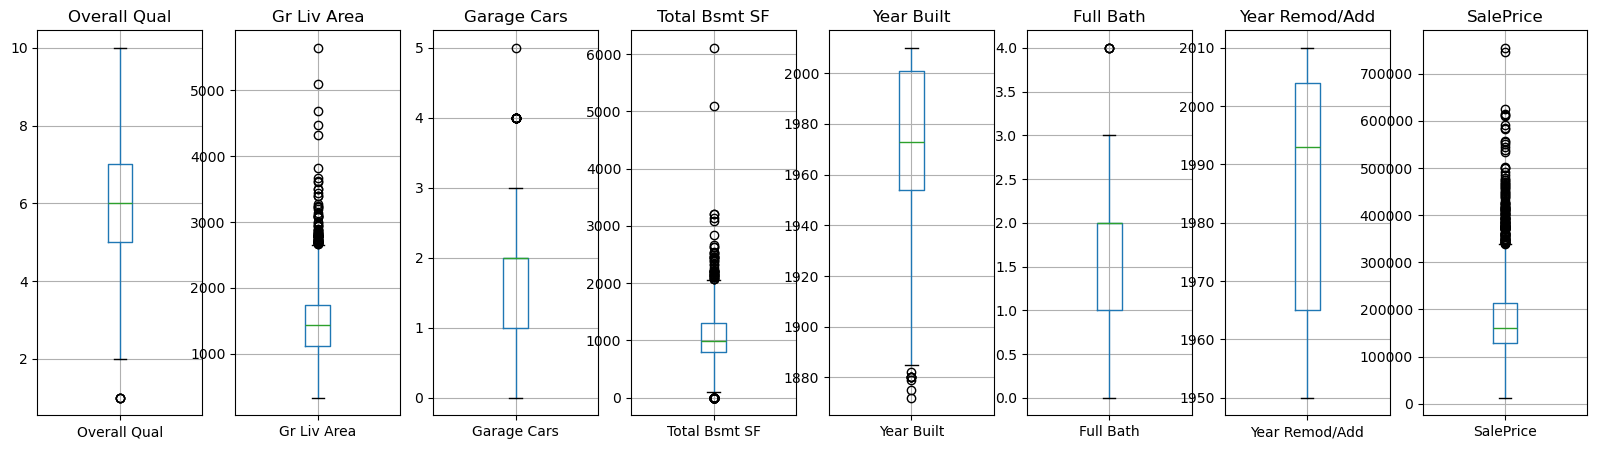

In [22]:
# Let's now visualize the distribution of several predictors and the target variable using boxplots 
# to identify potential outliers that might impact the model evaluation
def plot_boxplots(df):
    fig, axes = plt.subplots(1, len(df.columns), figsize=(20, 5))

    for i, column_name in enumerate(df.columns):
        df.boxplot(column=column_name, ax=axes[i])
        axes[i].set_title(column_name)

    plt.show()

plot_boxplots(df_model)

From above, you see there's outliers from features like MedInc, HousePrice and Population which adversely affect model performance, it's crucial to address them.

### What are Outliers?

An **outlier** is a **value that is much higher or lower than most of the other values** in your data.

* Think of it as the “weird one” that doesn’t fit with the rest.
* Outliers can appear in any type of data: numbers, prices, heights, ages, etc.

### **Example**:

Imagine you are looking at house prices in a neighborhood (in dollars):

```
200,000, 210,000, 190,000, 205,000, 500,000
```

* Most houses are around **200,000** → that’s normal.
* The **500,000 house** is **much higher than the rest** → this is an **outlier**.

---

### Another Example with Test Scores:

Test scores:

```
85, 90, 88, 92, 25
```

* Most students scored between 85–92.
* The score **25** is **way lower than the others** → that’s an **outlier**.

---

### **Why it matters**:

* Outliers can **affect averages**: for the house example, the average price is inflated by the 500,000 house.
* They can also **mess up predictions** in machine learning models like linear regression.

---

💡 **Tip:** Outliers are **not always wrong** - sometimes they are real extreme cases (like a mansion in a neighborhood). But it’s important to **notice them** before analyzing data.

In [23]:
#Function to remove outliers
def remove_outliers(df):
    df_no_outliers = df.copy()

    for column_name in df.columns:
        Q1 = df[column_name].quantile(0.25)
        Q3 = df[column_name].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_no_outliers[column_name] = df_no_outliers[column_name].apply(
            lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x
        )
        
        return df_no_outliers

df_model_new = remove_outliers(df_model)

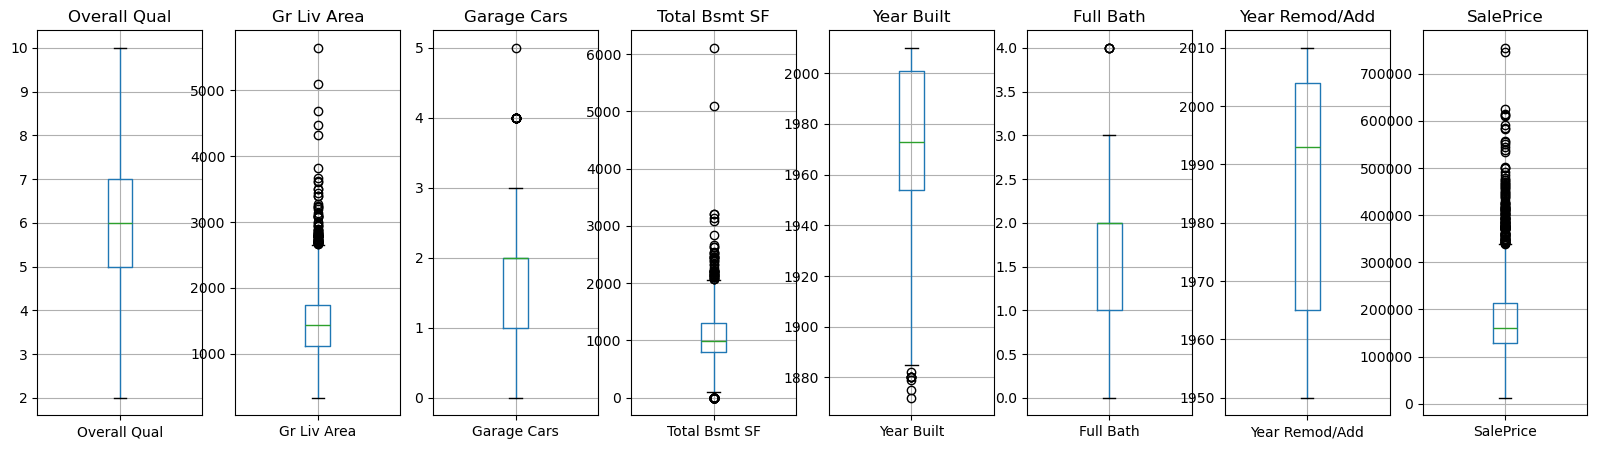

In [24]:
plot_boxplots(df_model_new)

### Refitting

In [25]:
#Re-fitting the model after `Outlier removal`.
#Converting selected columns in the housing dataset to numeric
cols_to_convert = [ "Overall Qual", "Gr Liv Area", "Garage Cars", "Total Bsmt SF", "Year Built", "Full Bath", "Year Remod/Add"]
df_model_new[cols_to_convert] = df_model_new[cols_to_convert].apply(pd.to_numeric, errors="coerce")
df_model_new["SalePrice"] = pd.to_numeric(df_model_new["SalePrice"], errors="coerce")

# Adding constant to the features
X = sm.add_constant(df_model_new.drop("SalePrice", axis=1))
y = df_model_new["SalePrice"]

# fit using an OLS Regression models using start model
model = sm.OLS(y, X).fit()

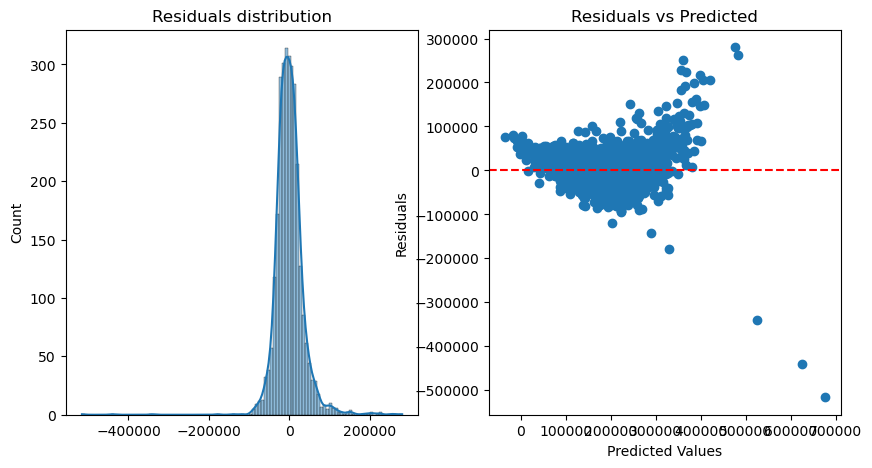

Model coefficients:
 const            -1.219608e+06
Overall Qual      1.968172e+04
Gr Liv Area       5.622412e+01
Garage Cars       1.331908e+04
Total Bsmt SF     3.338644e+01
Year Built        2.721788e+02
Full Bath        -9.463447e+03
Year Remod/Add    3.103064e+02
dtype: float64


In [26]:
# visualize the distribution of residuals and their relationship with predicted values
residuals = model.resid

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")

plt.subplot(1,2,2)
plt.scatter(model.predict(X), residuals)
plt.axhline(y=0, color="red", linestyle='--')
plt.title("Residuals vs Predicted")
plt.ylabel("Residuals")
plt.xlabel("Predicted Values")
plt.show()

print("Model coefficients:\n", model.params)

## Evaluation

In [29]:
# Compute and interprete the R^2 and MSE Metrics to evaluate the performance of the L.R model on the housing data. 
predictions = model.predict(X)
# Baseline RMSE score
rmse_baseline = np.sqrt(mean_squared_error(y, predictions))

print("R square Score:", r2_score(y, predictions))
print("Baseline MSE:", mean_squared_error(y, predictions))
print("Baseline RMSE:", rmse_baseline)
print("Baseline MAE:", mean_absolute_error(y, predictions))

R square Score: 0.792307907734518
Baseline MSE: 1325014383.0030906
Baseline RMSE: 36400.74701160803
Baseline MAE: 23878.73521994852


The `R^2` score measures the proportion of variance in the dependent varible explained by the independent variables, `While` `MSE's` quantifies the average square difference between the predicted and actual values providing insight into the model accuracy after outlier removal.

Here, we can see that without outliers, the R^2 score increased from  `0.79` to `0.792` indicating a better fit, RMSE decrease from `36434` to `36400` showing improved predict accuracy.

---

1. R² Score
Before → After: 0.7919 → 0.7923
This is a very small improvement (~0.0004)

**Interpretation**:
The model explains slightly more variance after removing outliers, but the improvement is marginal. This suggests outliers were not heavily distorting the overall variance structure.

---
2. RMSE (Root Mean Squared Error)
Before → After: 36434 → 36400 (⬇ decrease)

**What RMSE measures**:

Penalizes large errors more heavily (because of squaring)

**Interpretation**:
The reduction in RMSE indicates that large prediction errors have slightly decreased, meaning the model is now less sensitive to extreme deviations.

---
3. MAE (Mean Absolute Error)
Before → After: 23887 → 23878 (⬇ slight decrease)

**Interpretation**:
The average prediction error improved very slightly, meaning predictions are marginally closer to actual values on average

---

**Generally**: After removing outliers, the model shows a slight improvement across all evaluation metrics. The R² score increased marginally from 0.7919 to 0.7923, indicating a negligible but positive improvement in explained variance. The RMSE decreased from 36,434 to 36,400, suggesting a small reduction in large prediction errors, meaning the model is slightly less influenced by extreme values. Similarly, the MAE decreased from 23,887 to 23,878, indicating a minor improvement in average prediction accuracy. Overall, these changes suggest that outlier removal had a limited but positive impact, and the dataset was already relatively stable prior to cleaning.

## Conclusion

- We built a simple model
- You can try improving it with other algorithms